# Regresión Lineal Múltiple de Lattice Physics

Incluimos las librerías que nos permitirán manejar los datos de mejor manera, como la librería Pandas que nos permitirá realizar un preprocesamiento mediante `df.info()`. Para este trabajo usaremos el dataset obtenido de: https://archive.ics.uci.edu/dataset/1091/lattice-physics+(pwr+fuel+assembly+neutronics+simulation+results)

In [18]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librería para manipulación y analisis de datos
import pandas as pd

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [19]:
#nos conectamos a google Drive
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## 2 Regresión lineal con multiples variables
Se implementa la regresión lineal multivariable para predecir variables físicas de alta precisión en un entorno industrial. El archivo raw.csv contiene un conjunto de entrenamiento con 24,000 instancias obtenidas de simulaciones neutrónicas de reactores nucleares. Tiene un total de 41 columnas Las primeras 40 columnas del dataset representan las características de entrada del sistema, como: el enriquecimiento del combustible, la densidad del moderador y la geometría del reactor, las cuales actúan como las variables predictoras. La columna restante (columna 0) representa el factor de multiplicación de neutrones ($k_{inf}$), que es el número que nos dice si un reactor nuclear es seguro y estable, este es el valor escalar objetivo a predecir mediante el modelo.

### 2.1 Normalización de características
Al visualizar los datos se puede observar que las caracteristicas tienen diferentes magnitudes, por lo cual se debe transformar cada valor en una escala de valores similares, esto con el fin de que el descenso por el gradiente pueda converger mas rapidamente.

In [20]:
# Cargar datos
#recuperación de datos con np, no se especifica que separa las columnas porque solo son espacios
#data = np.loadtxt('/content/drive/MyDrive/SIS420/raw.csv')
#recupera los datos con pandas, especificando que pueden estar separados por uno o más espacios '\s+' y que el dataset no tiene cabeceras
df = pd.read_csv('/content/gdrive/MyDrive/SIS420/raw.csv', sep=r'\s+', header=None)
# Verificamos que ahora sí existan 41 columnas sin valores nulos y los tipos de datos
print(df.info())
data=df.values
X = data[:, 1:] #desde la segunda columna hasta la última
y = data[:, 0] #la primera columna es la que hay que predecir
m = y.size
print(m)
# imprimimos cantidad de características
n = X.shape[1]
print(n)

# Imprimir algunos puntos de datos para verificar la carga
# X[:,0] es la columna que será de unos, X[:,1] es la primera característica física
print('{:>10s}{:>10s}{:>10s}{:>10s}{:>10s}{:>10s}'.format('X[:,0]', 'X[:,1]', 'X[:,2]', 'X[:,3]', 'X[:,4]', 'y'))
print('-'*64)
for i in range(10):
    # Usamos .4f para mostrar 4 decimales, que es la precisión de tu archivo raw.csv
    print('{:10.4f}{:10.4f}{:10.4f}{:10.4f}{:10.4f}{:12.4f}'.format(X[i, 0], X[i, 1], X[i, 2], X[i, 3], X[i, 4], y[i]))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       24000 non-null  float64
 1   1       24000 non-null  float64
 2   2       24000 non-null  float64
 3   3       24000 non-null  float64
 4   4       24000 non-null  float64
 5   5       24000 non-null  float64
 6   6       24000 non-null  float64
 7   7       24000 non-null  float64
 8   8       24000 non-null  float64
 9   9       24000 non-null  float64
 10  10      24000 non-null  float64
 11  11      24000 non-null  float64
 12  12      24000 non-null  float64
 13  13      24000 non-null  float64
 14  14      24000 non-null  float64
 15  15      24000 non-null  float64
 16  16      24000 non-null  float64
 17  17      24000 non-null  float64
 18  18      24000 non-null  float64
 19  19      24000 non-null  float64
 20  20      24000 non-null  float64
 21  21      24000 non-null  float64
 22

La desviación estándar es la forma que se usará para medir la variación de las características que son los 40 parámetros físicos. Básicamente, dice qué tanto se alejan los valores de la media: la regla general es que la gran mayoría de los parámetros físicos van a caer en un rango de $\pm 2$ en relación a la desviaciones estándar de la media. Usaremos la función `std` para calcular la desviacion estandar.

In [21]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0) #calculamos el promedio de cada característica
    sigma = np.std(X, axis = 0) #calculamos la desviación estándar de cada columna
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [22]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[1.8620857  3.56261467 1.11235914 ... 2.86539965 4.7738198  3.53937285]
 [1.78655768 2.35476558 1.04792854 ... 4.68114817 3.21549438 3.97267229]
 [1.82618744 3.03799709 4.71951659 ... 1.37555387 4.36332004 2.98854614]
 ...
 [1.81256374 1.83043853 4.867422   ... 4.94588229 3.6561804  2.51979689]
 [1.98703052 1.46531626 2.60956144 ... 4.06657492 4.52332245 3.43531235]
 [1.80503606 3.82814723 2.58622584 ... 1.59234561 1.7857543  2.5275172 ]]
Media calculada: [1.88355865 2.85569412 2.85999447 2.85745069 2.86755424 2.84899669
 2.84012294 2.86736038 2.85094753 2.85509725 2.85417026 2.85461041
 2.84507288 2.86589102 2.84693051 2.85199681 2.83338814 2.84478916
 2.85602518 2.86721222 2.85342425 2.84677056 2.84801538 2.84536414
 2.86044432 2.87574061 2.84388442 2.85380138 2.83758827 2.84135921
 2.84611787 2.84623939 2.83914594 2.83885017 2.84667828 2.84587117
 2.838678   2.84488498 2.85197836 2.85124855]
Desviación estandar calculada: [0.12001554 1.24001393 1.23827819 1.23717783 1.23455794 1.24

Ya que la función `featureNormalize` fue probada, procedemos a añadir el término de intersección a `X_norm`, que es una columna de unos para $x_{0}$:

In [23]:
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
print(X[:,0])
print(y)

[1. 1. 1. ... 1. 1. 1.]
[1.3263  1.34149 1.33034 ... 1.31469 1.29903 1.34212]


### 2.2 Descenso por el gradiente
Creamos la función de costo que es el medidor de error para saber que tan mala es la predicción `computeCostMulti`:
$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

In [24]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J

Para después ejecutar la función de Descenso por el Gradiente `gradientDescentMulti`, esta es la función que mejora la predicción hecha.

In [25]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

### 2.2.1 Seleccionando coheficientes de aprendizaje

theta calculado por el descenso por el gradiente: [ 1.32513941e+00 -7.73567322e-04  1.66073156e-03  1.67788842e-03
  1.61690870e-03  1.62794251e-03  1.58614645e-03  1.47610239e-03
  1.61882232e-03  3.26685979e-03  3.35615246e-03  3.22454908e-03
  3.20878698e-03  3.23944825e-03  3.08191878e-03  2.97436044e-03
  1.59587185e-03  3.34915496e-03  3.22778790e-03  3.18819007e-03
  3.24715222e-03  3.04715971e-03  2.97149566e-03  3.38900065e-03
  3.34176499e-03  3.13545004e-03  2.95386716e-03  1.58208230e-03
  3.31637068e-03  3.27735662e-03  3.02662930e-03  2.93567552e-03
  3.20508511e-03  2.98208182e-03  2.87182148e-03  1.49939339e-03
  2.86426296e-03  2.83975567e-03  1.43162903e-03  2.80379079e-03
  1.40389578e-03]
El valor de factor de multiplicación de neutrones predicho para los parámetros dados es: 1.3408


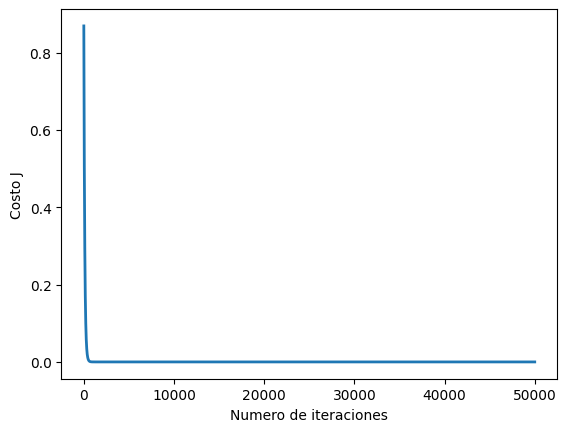

In [26]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.005 # alpha = 0.003
num_iters = 50000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Estimar el factor de multiplicación de neutrones (k_inf) con las siguientes características
X_array = [1, 1.8621, 3.5626, 1.1124, 4.2081, 1.4127, 2.2710, 3.9506, 3.6270, 4.6003,
           2.8920, 3.9709, 4.9294, 2.5934, 2.8076, 3.1016, 3.4527, 2.1584, 2.1981,
           2.7347, 3.9045, 0.7619, 0.9013, 3.8382, 3.5110, 0.9223, 2.9248, 4.6566,
           1.6174, 1.2639, 3.3939, 3.9660, 3.3939, 3.9660, 3.3939, 3.9660, 3.3939,
           3.9660, 3.3939, 3.9660, 3.3939]
X_array[1:] = (X_array[1:] - mu) / sigma
k_inf_predicho= np.dot(X_array, theta)

print('El valor de factor de multiplicación de neutrones predicho para los parámetros dados es: {:.4f}'.format(k_inf_predicho))

### 2.3 Ecuacion de la Normal
Una manera de calcular rapidamente el modelo de una regresion lineal es:
$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las características, se debe agregar la columna de unos a la matriz $X$ para tener el término de intersección($\theta_0$).

In [27]:
# Cargar datos
#data = np.loadtxt('/content/drive/MyDrive/SIS420/raw.csv')
df = pd.read_csv('/content/gdrive/MyDrive/SIS420/raw.csv', sep=r'\s+', header=None)
data=df.values
X = data[:, 1:]
y = data[:, 0]
m = y.size
print(m)
X = np.concatenate([np.ones((m, 1)), X], axis=1)

24000


In [28]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [29]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar el precio para una casa de superficie de 1650 sq-ft y tres dormitorios

X_array = [1, 1.8621, 3.5626, 1.1124, 4.2081, 1.4127, 2.2710, 3.9506, 3.6270, 4.6003,
           2.8920, 3.9709, 4.9294, 2.5934, 2.8076, 3.1016, 3.4527, 2.1584, 2.1981,
           2.7347, 3.9045, 0.7619, 0.9013, 3.8382, 3.5110, 0.9223, 2.9248, 4.6566,
           1.6174, 1.2639, 3.3939, 3.9660, 3.3939, 3.9660, 3.3939, 3.9660, 3.3939,
           3.9660, 3.3939, 3.9660, 3.3939]
k_inf_normal= np.dot(X_array, theta)

print('El valor de factor de multiplicación de neutrones predicho por la normal para los parámetros dados es: {:.4f}'.format(k_inf_normal))

Theta calculado a partir de la ecuación de la normal: [ 1.10057762 -0.00644556  0.00133928  0.00135502  0.00130693  0.00131864
  0.00127508  0.00118825  0.00130338  0.0026267   0.00270264  0.00258888
  0.00258019  0.00260947  0.00248084  0.00239416  0.001279    0.00270225
  0.00258588  0.00256492  0.00261501  0.00246739  0.00239021  0.00271636
  0.00270424  0.00251948  0.00238467  0.00127728  0.00269729  0.00263528
  0.00243966  0.0023621   0.00257597  0.00239926  0.00231666  0.00120549
  0.00231021  0.00228094  0.00115111  0.00226488  0.00112598]
El valor de factor de multiplicación de neutrones predicho por la normal para los parámetros dados es: 1.3408


Concluimos en que la Ecuación de la Normal es un método directo mientras que el Descenso por el Gradiente es un proceso iterativo. Sin embargo, ambos buscan minimizar la función de costo por eso demostramos que al intentar minimizar la misma función, llegaron a la misma predicción del factor de multiplicación de neutrones.